11) Develop a graphical presentation containing information about a specific gene or genes, the medicinal substances interacting with that gene or those genes, and the pharmaceutical products containing the corresponding medicinal substance. The decision regarding whether the graphic presentation focuses on a specific gene or all genes is left to your discretion. When making this choice, consider the readability and visual appeal of the presentation.

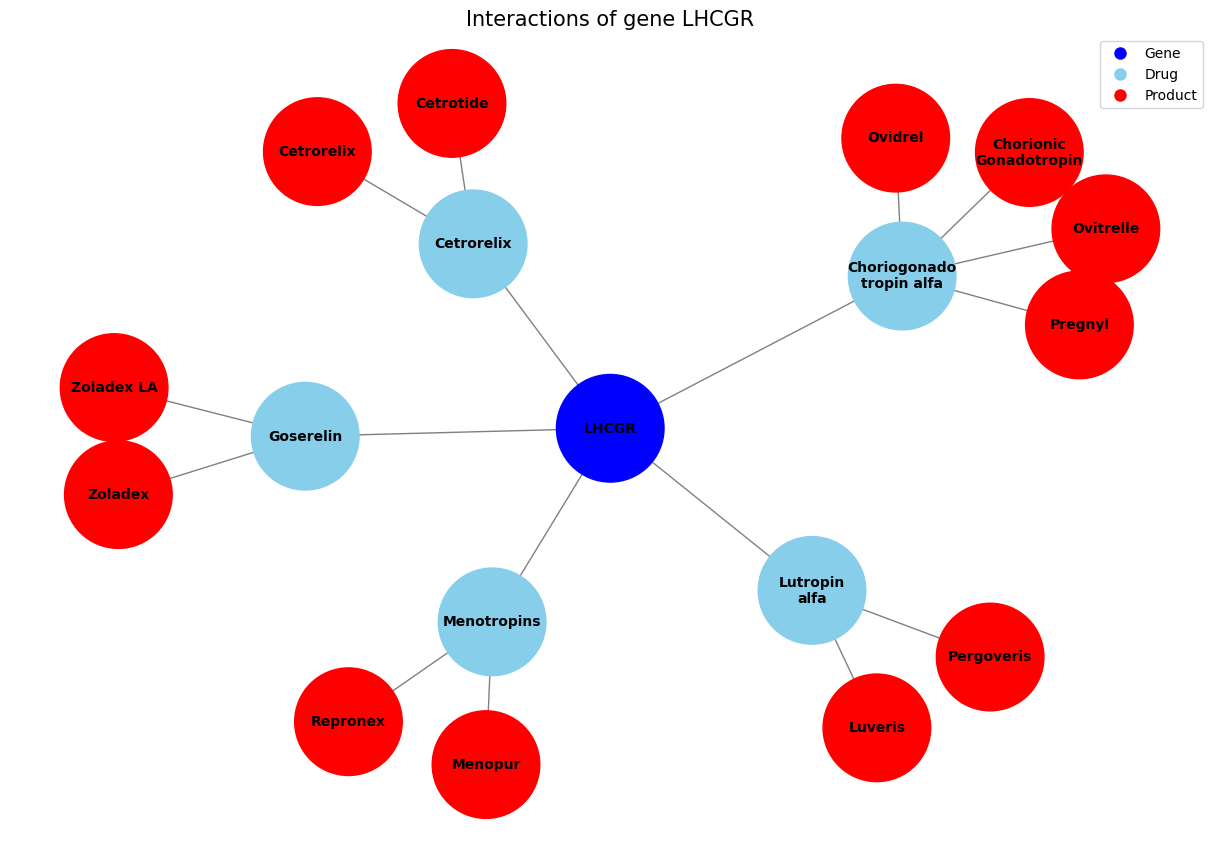

In [1]:
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
import networkx as nx
import textwrap

# Define the gene of interest
gene_name = 'LHCGR'
file_path = 'drugbank_partial.xml'
namespace = {'drugbank': 'http://www.drugbank.ca'}

# Initialize the graph
G = nx.Graph()
G.add_node(gene_name, color='blue', label=gene_name)

# Parse the XML file and extract relevant information
for event, elem in ET.iterparse(file_path, events=('start', 'end')):
    if elem.tag == f"{{{namespace['drugbank']}}}drug" and event == 'end':
        interacts_with_gene = False
        genes = elem.findall('.//drugbank:gene-name', namespace)
        for gene in genes:
            if gene.text == gene_name:
                interacts_with_gene = True
                break

        if interacts_with_gene:
            # Add drug node and edge
            drug_label = elem.find('drugbank:name', namespace).text
            drug_id = f'{drug_label} (drug)'
            G.add_node(drug_id, color='skyblue', label=drug_label)
            G.add_edge(gene_name, drug_id)

            # Add product nodes and edges
            for product in elem.findall('.//drugbank:product', namespace):
                product_label = product.find('drugbank:name', namespace).text
                product_id = f'{product_label} (product)'
                G.add_node(product_id, color='red', label=product_label)
                G.add_edge(drug_id, product_id)
        elem.clear()

# Define the layout and colors for the graph
pos = nx.spring_layout(G)
colors = [G.nodes[node]['color'] for node in G.nodes]
labels = {node: '\n'.join(textwrap.wrap(G.nodes[node]['label'], width=12)) for node in G.nodes}

# Draw the graph
plt.figure(figsize=(12, 8))
nx.draw(G, pos, labels=labels, with_labels=True, node_size=6000, node_color=colors, font_size=10, font_weight='bold', edge_color='gray')

# Add legend
legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=10, label='Gene'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='skyblue', markersize=10, label='Drug'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=10, label='Product')
]
plt.legend(handles=legend_elements, loc='best')

# Set the title and show the plot
plt.title(f'Interactions of gene {gene_name}', fontsize=15)
plt.show()